In [1]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
os.environ["PATH"] = "/vast/palmer/apps/avx2/software/texlive/20220321-GCC-12.2.0/bin/x86_64-linux:" + os.environ["PATH"]
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{lmodern}",
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6,
    "figure.figsize": [7, 4.9],
    "svg.fonttype": "none",
    "image.cmap": "viridis",
})

In [3]:
os.environ["JAX_PLATFORMS"] = "cpu"

import jax
jax.config.update("jax_enable_x64", True)

from jaxdem.utils.h5 import load
from jaxdem.utils.packing_utils import compute_packing_fraction

In [4]:
UNIFORM_JAM_DIR = Path("/home/rg2248/palmer_scratch/data/summer-26/jam-uniform/n-1000")
UNIFORM_JAMMED_DIR = Path("/home/rg2248/project/friction/data/local-friction/uniform/jammed")
UNIFORM_SAMPLE_DIR = Path("/home/rg2248/project/friction/data/local-friction/uniform/sample")
CS_PHI_J_PATH = Path("cs-phi_j.csv")
CS_Z_C_PATH = Path("cs-z_c.csv")

# Must match friction/uniform/sample/sample_friction.py
N_ORIENTATIONS = 5009
N_POINTS = 5003
N_PARTICLES = 1000

CONTACT_TYPES = {
    "ss": ("Small--small", "s", "blue"),
    "sl": ("Small--large", "^", "red"),
    "ll": ("Large--large", "D", "black"),
}

COORDINATION_TYPES = {
    "all": ("All contacts", "o", "0.35"),
    **CONTACT_TYPES,
}

In [5]:
def load_mu_values(jam_dir, sample_dir):
    jam_mu = set()
    for run_dir in jam_dir.iterdir():
        if not run_dir.is_dir() or not run_dir.name.isdigit():
            continue
        for mu_dir in run_dir.iterdir():
            if mu_dir.is_dir() and mu_dir.name.startswith("mu-"):
                jam_mu.add(float(mu_dir.name.removeprefix("mu-")))

    sample_mu = {
        float(path.stem.removeprefix("mu-"))
        for path in sample_dir.glob("mu-*.npz")
    }
    return np.array(sorted(jam_mu & sample_mu))


def jammed_packing_fractions(data_root, mu_eff):
    packing_fractions = []

    for run_dir in sorted(data_root.iterdir(), key=lambda path: int(path.name)):
        if not run_dir.is_dir() or not run_dir.name.isdigit():
            continue

        run_path = run_dir / f"mu-{mu_eff}"
        state_path = run_path / "state.h5"
        system_path = run_path / "system.h5"
        if not state_path.exists() or not system_path.exists():
            continue

        state = load(state_path)
        system = load(
            system_path,
            state_shape=state.shape,
            warn_missing=False,
        )
        packing_fractions.append(float(compute_packing_fraction(state, system)))

    if not packing_fractions:
        raise FileNotFoundError(f"No jammed runs found for mu_eff={mu_eff} in {data_root}")

    return np.asarray(packing_fractions)


def mean_sem(values):
    values = np.asarray(values)
    mean = float(values.mean())
    sem = float(values.std(ddof=1) / np.sqrt(values.size)) if values.size > 1 else 0.0
    return mean, sem


def jammed_coordination_numbers(jammed_dir, mu_eff):
    data = dict(np.load(jammed_dir / f"mu-{mu_eff}.npz"))
    missing = [key for key in COORDINATION_TYPES if f"z_c_{key}" not in data]
    if missing:
        raise KeyError(
            f"Missing z_c arrays {missing} in {jammed_dir}/mu-{mu_eff}.npz; "
            "re-run friction/uniform/jammed/jammed_friction.py"
        )

    return {
        key: mean_sem(data[f"z_c_{key}"])
        for key in COORDINATION_TYPES
    }


def weighted_sampled_mean(jammed_dir, sample_dir, mu_eff, sampled_means):
    jammed = dict(np.load(jammed_dir / f"mu-{mu_eff}.npz"))
    total = len(jammed["all"])
    return sum(
        len(jammed[key]) / total * sampled_means[key]
        for key in CONTACT_TYPES
    )


def weighted_sampled_sem(jammed_dir, mu_eff, sampled_sems):
    jammed = dict(np.load(jammed_dir / f"mu-{mu_eff}.npz"))
    total = len(jammed["all"])
    terms = [
        len(jammed[key]) / total * sampled_sems[key]
        for key in CONTACT_TYPES
    ]
    return float(np.sqrt(sum(term**2 for term in terms)))


def sampled_friction_stats(sample_dir, mu_eff, contact_key):
    values = np.asarray(np.load(sample_dir / f"mu-{mu_eff}.npz")[contact_key])
    values = values.reshape(N_ORIENTATIONS, N_POINTS)

    orientation_means = values.mean(axis=1)
    mean = float(values.mean())
    sem = float(orientation_means.std(ddof=1) / np.sqrt(N_ORIENTATIONS))

    return mean, sem

In [6]:
mu_eff = load_mu_values(UNIFORM_JAM_DIR, UNIFORM_SAMPLE_DIR)

phi_j_mean = np.zeros(mu_eff.size)
phi_j_sem = np.zeros(mu_eff.size)
sampled_mean = {key: np.zeros(mu_eff.size) for key in CONTACT_TYPES}
sampled_sem = {key: np.zeros(mu_eff.size) for key in CONTACT_TYPES}
sampled_mean_all = np.zeros(mu_eff.size)
sampled_sem_all = np.zeros(mu_eff.size)
z_c_mean = {key: np.zeros(mu_eff.size) for key in COORDINATION_TYPES}
z_c_sem = {key: np.zeros(mu_eff.size) for key in COORDINATION_TYPES}

for i, mu in enumerate(mu_eff):
    phi_j_mean[i], phi_j_sem[i] = mean_sem(
        jammed_packing_fractions(UNIFORM_JAM_DIR, mu)
    )

    coordination = jammed_coordination_numbers(UNIFORM_JAMMED_DIR, mu)
    for key in COORDINATION_TYPES:
        z_c_mean[key][i], z_c_sem[key][i] = coordination[key]

    for key in CONTACT_TYPES:
        mean, sem = sampled_friction_stats(UNIFORM_SAMPLE_DIR, mu, key)
        sampled_mean[key][i] = mean
        sampled_sem[key][i] = sem

    sampled_mean_all[i] = weighted_sampled_mean(
        UNIFORM_JAMMED_DIR,
        UNIFORM_SAMPLE_DIR,
        mu,
        {key: sampled_mean[key][i] for key in CONTACT_TYPES},
    )
    sampled_sem_all[i] = weighted_sampled_sem(
        UNIFORM_JAMMED_DIR,
        mu,
        {key: sampled_sem[key][i] for key in CONTACT_TYPES},
    )

cs_mu_local, cs_phi_j = np.loadtxt(CS_PHI_J_PATH, delimiter=",", unpack=True)
cs_mu_local_zc, cs_z_c = np.loadtxt(CS_Z_C_PATH, delimiter=",", unpack=True)

/tmp/ipykernel_2991368/1474782301.py:14: RuntimeWarning: h5: State: unknown saved fields ['unique_id'] - skipping
  jammed_packing_fractions(UNIFORM_JAM_DIR, mu)


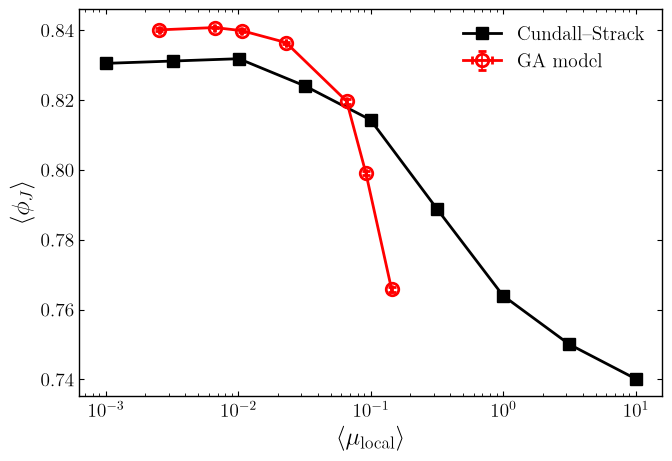

In [9]:
fig, ax = plt.subplots()

order = np.argsort(sampled_mean_all)
x = sampled_mean_all[order]
xerr = sampled_sem_all[order]
y = phi_j_mean[order]
yerr = phi_j_sem[order]

ax.errorbar(
    x,
    y,
    xerr=xerr,
    yerr=yerr,
    color="red",
    marker="o",
    markersize=9,
    markerfacecolor="none",
    markeredgewidth=2,
    markeredgecolor="red",
    linestyle="-",
    capsize=3,
    elinewidth=1.2,
    label="GA model",
)

order_cs = np.argsort(cs_mu_local)
ax.plot(
    cs_mu_local[order_cs],
    cs_phi_j[order_cs],
    color="black",
    linestyle="-",
    marker="s",
    markerfacecolor="black",
    markeredgecolor="black",
    markersize=9,
    label="Cundall--Strack",
)

ax.set_xlabel(r"$\langle\mu_{\mathrm{local}}\rangle$")
ax.set_ylabel(r"$\langle\phi_J\rangle$")
ax.set_xscale("log")
ax.legend(frameon=False)
plt.tight_layout()

figure_path = Path("../figures/jam/phi_j.png")
figure_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(figure_path, dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
fig, ax = plt.subplots()

order = np.argsort(sampled_mean_all)
x = sampled_mean_all[order]
xerr = sampled_sem_all[order]
y = z_c_mean["all"][order]
yerr = z_c_sem["all"][order]

ga_line = ax.errorbar(
    x,
    y,
    xerr=xerr,
    yerr=yerr,
    color="red",
    marker="o",
    markersize=9,
    markerfacecolor="none",
    markeredgewidth=2,
    markeredgecolor="red",
    linestyle="-",
    capsize=3,
    elinewidth=1.2,
    label="GA model",
)

order_cs = np.argsort(cs_mu_local_zc)
(cs_line,) = ax.plot(
    cs_mu_local_zc[order_cs],
    cs_z_c[order_cs],
    color="black",
    linestyle="-",
    marker="s",
    markerfacecolor="black",
    markeredgecolor="black",
    markersize=9,
    label="Cundall--Strack",
)

ax.set_xlabel(r"$\langle\mu_{\mathrm{local}}\rangle$")
ax.set_ylabel(r"$\langle z_c\rangle$")
ax.set_xscale("log")
ax.legend(frameon=False)
plt.tight_layout()

figure_path = Path("../figures/jam/z_c.png")
figure_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(figure_path, dpi=600, bbox_inches="tight")
plt.show()